# 4PL model for Automated ELISA Analysis

This project demonstrates a Python-based four-parameter logistic (4PL) model developed to automate quantitative ELISA result calculations.

The workflow was designed to reduce manual data processing, standardize the analysis, and improve the consistency and reproducibility of reported results.

### Objectives

The automated workflow was designed to:

 - Reduce manual data processing and result calculation time
 - Standardize the curve-fitting and calculation workflow
 - Generate calibration curves automatically
 - Calculate sample concentrations from measured OD values
 - Provide quantitative metrics for assessing the fitted standard curve

### Workflow

The analysis consists of the following steps:

1. Generate or import ELISA data
2. Calculate average OD values from duplicate measurements and correct the measurements using the average blank OD
4. Fit a four-parameter logistic calibration curve
5. Evaluate the quality of the fitted curve
6. Back-calculate sample concentrations from measured OD values
7. Correct concentrations for sample dilution
8. Summarize the calculated results

### Packages Used

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import re

### Generating an ELISA Dataset

To demonstrate the complete analysis workflow without using confidential experimental data, a representative ELISA dataset is generated.

The simulated dataset contains duplicate standard and sample measurements with controlled random variation. A known 4PL relationship is used to generate the standard-curve data, allowing the fitted model to be evaluated against a known underlying response.

The dataset is structured to resemble the type of raw plate data used by the subsequent preprocessing and analysis steps.

In [2]:
def simulate_elisa_data(seed=42):
    rng = np.random.default_rng(seed)

    STD = [30 * (0.75 ** i) for i in range(16)]

    A_true, B_true, C_true, D_true = 3.0, 1.3, 1.5, 0.03

    def noisy_duplicate(x_vals, A, B, C, D, noise=0.03):
        base = four_pl(np.array(x_vals), A, B, C, D)
        rep1 = base * (1 + rng.normal(0, noise, len(base)))
        rep2 = base * (1 + rng.normal(0, noise, len(base)))
        return rep1, rep2
    
    def four_pl(logx, A, B, logEC50, D):
        return D + (A - D) / (1 + 10**((logEC50 - logx) * B))

    std1_r1, std1_r2 = noisy_duplicate(STD[0:8], A_true, B_true, C_true, D_true)
    std2_r1, std2_r2 = noisy_duplicate(STD[8:16], A_true, B_true, C_true, D_true)

    sample_names = ["A1", "A2", "A3"]
    timepoints = ["Assay 10x", "Assay 50x", "Assay 100x", "Assay 1000x",
                  "Assay 5000x", "Assay 10000x", "TestSample 100x", "TestSample 1000x"]

    sample_cols = {}
    for name in sample_names:
        base_curve = rng.uniform(0.05, 3.5, size=8)
        rep1 = base_curve * (1 + rng.normal(0, 0.05, 8))
        rep2 = base_curve * (1 + rng.normal(0, 0.05, 8))
        sample_cols[name] = (rep1, rep2)

    data = {
        "Unnamed: 2": std1_r1, "Unnamed: 3": std1_r2,
        "Unnamed: 4": std2_r1, "Unnamed: 5": std2_r2,
        "Unnamed: 6": sample_cols["A1"][0], "Unnamed: 7": sample_cols["A1"][1],
        "Unnamed: 8": sample_cols["A2"][0], "Unnamed: 9": sample_cols["A2"][1],
        "Unnamed: 10": sample_cols["A3"][0], "Unnamed: 11": sample_cols["A3"][1],
        "Unnamed: 12": rng.uniform(0.02, 0.03, 8),
        "Unnamed: 13": rng.uniform(0.02, 0.03, 8),
    }
    od_df = pd.DataFrame(data).round(3)

    label_rows = []
    for i in range(8):
        row = {
            "Unnamed: 2": STD[i], "Unnamed: 3": np.nan,
            "Unnamed: 4": STD[i + 8], "Unnamed: 5": np.nan,
            "Unnamed: 6": f"A1 {timepoints[i]}", "Unnamed: 7": np.nan,
            "Unnamed: 8": f"A2 {timepoints[i]}", "Unnamed: 9": np.nan,
            "Unnamed: 10": f"A3 {timepoints[i]}", "Unnamed: 11": np.nan,
            "Unnamed: 12": np.nan, "Unnamed: 13": np.nan,
        }
        label_rows.append(row)
    label_df = pd.DataFrame(label_rows)

    fake_df = pd.concat([od_df, label_df], ignore_index=True)
    return fake_df, STD

fake_df, STD = simulate_elisa_data()
df = fake_df
df

,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,3.027000,2.998,3.000000,2.929,1.218,1.214,0.551,0.508,2.927,2.669,0.024,0.022
1,2.906000,2.923,2.639000,2.689,1.364,1.333,0.463,0.456,0.64,0.595,0.023,0.029
2,3.068000,3.079,1.976000,1.956,1.614,1.694,2.315,2.373,0.133,0.131,0.021,0.028
3,3.085000,3.070,1.016000,1.028,0.712,0.726,1.637,1.733,0.359,0.344,0.029,0.027
4,2.824000,3.006,0.507000,0.517,0.501,0.462,2.086,1.957,2.488,2.494,0.025,0.024
5,2.883000,3.101,0.281000,0.291,1.71,1.664,2.664,2.711,1.637,1.750,0.022,0.026
6,3.011000,3.042,0.193000,0.198,0.869,0.813,2.097,2.310,0.555,0.596,0.023,0.026
7,2.970000,2.921,0.136000,0.135,2.387,2.285,1.849,1.930,1.65,1.844,0.026,0.026
8,30.000000,NaN,3.003387,NaN,A1 Assay 10x,NaN,A2 Assay 10x,NaN,A3 Assay 10x,NaN,NaN,NaN
9,22.500000,NaN,2.252541,NaN,A1 Assay 50x,NaN,A2 Assay 50x,NaN,A3 Assay 50x,NaN,NaN,NaN


### Data Preprocessing

In [3]:
# Optional workflow for importing raw Excel data and selecting the relevant OD section
#df = pd.read_excel(r"xx", sheet_name= "yy")
#wanted_OD = "zz"

# reset index so positions are clean
#df = df.reset_index(drop=True)

# find the first row where column 0 matches
#mask = df.iloc[:, 0] == wanted_OD
#idx = df.index[mask][0]

#new_df = df.loc[idx:].reset_index(drop=True)
#new_df = new_df.iloc[2:, 2:].reset_index(drop=True)

# Split the two sections first

# Raw OD values
od_data = df.iloc[:8].copy()

# sample names
label_data = df.iloc[8:].copy()

# Transforming raw OD values to numeric data
od_data = od_data.apply(pd.to_numeric, errors="coerce")

# The last two columns of the plate contain only blank samples.
blank_cols = od_data.columns[-2:]
blank_avg = od_data[blank_cols].mean().mean()
print("Average blank OD:", blank_avg)

# Subtract blank from every raw OD wells, then drop the blank columns
od_corrected = od_data.drop(columns=blank_cols).subtract(blank_avg)

# Calculate average OD of duplicates on the corrected values
sample_cols = od_corrected.columns
avg_results = {}

for i in range(0, len(sample_cols), 2):
    col1 = sample_cols[i]
    col2 = sample_cols[i + 1]
    sample_name = f"Sample_{i//2 + 1}"
    avg_results[sample_name] = od_corrected[[col1, col2]].mean(axis=1)

corrected_df = pd.DataFrame(avg_results)
corrected_df

Average blank OD: 0.0250625


,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5
0,2.987437,2.939437,1.190937,0.504438,2.772937
1,2.889437,2.638937,1.323438,0.434438,0.592437
2,3.048437,1.940937,1.628938,2.318937,0.106938
3,3.052437,0.996938,0.693937,1.659938,0.326437
4,2.889937,0.486938,0.456438,1.996437,2.465937
5,2.966937,0.260938,1.661938,2.662437,1.668438
6,3.001437,0.170438,0.815937,2.178437,0.550438
7,2.920437,0.110438,2.310937,1.864437,1.721938


### 4PL Curve Fitting

The blank-corrected standard concentrations and corresponding OD measurements are used to fit a four-parameter logistic (4PL) calibration model.

The 4PL model describes the sigmoidal relationship between analyte concentration and assay response. The four parameters represent the upper asymptote, slope, inflection point, and lower asymptote.

The fitted parameters are subsequently used both to generate the calibration curve and to back-calculate concentrations for unknown samples.

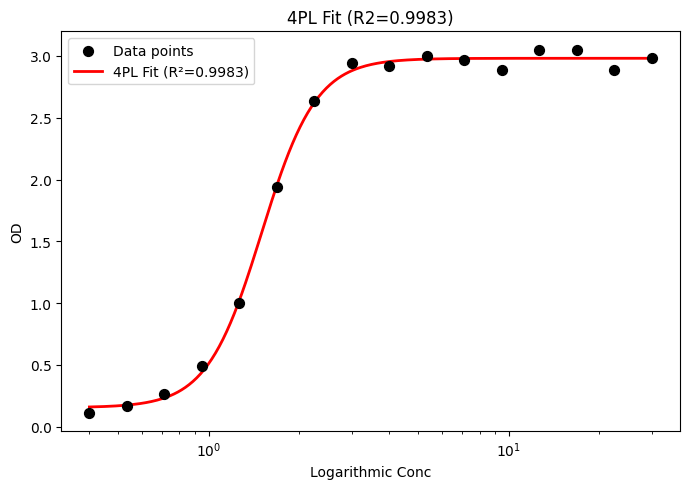

Top Asymptote: 2.9813736203805856
Slope: 4.770000585746708
Inflection point: 1.5023149800234654
Bottom Asymptote: 0.15366778632137945
Standard Curve Coefficient: 0.9982572050979912


In [4]:
# First 4 wells are STD and I will define the concentrations and then calculate average OD for all wells in A1 - H2 and 
# A3 - H4
x = np.array(STD) 

#Raw OD values
y = np.concatenate([
    corrected_df["Sample_1"].iloc[0:8].to_numpy(),
    corrected_df["Sample_2"].iloc[0:8].to_numpy()
])

# Remove zero/negative x (blank standard)
mask = x > 0
x = x[mask]
y = y[mask]
logx = np.log10(x)

# Initial guesses + bounds to anchor the fit correctly
p0 = [max(y)*2, 1.4, np.log10(np.median(x)), min(y)]
bounds = ([0, 0.01, -1, -0.05], [50, 10, 4, 0.5])

def four_pl(logx, A, B, logEC50, D):
    return D + (A - D) / (1 + 10**((logEC50 - logx) * B))

p, _ = curve_fit(four_pl, logx, y, p0=p0, bounds=bounds, method='trf',
                 ftol=1e-15, xtol=1e-15, gtol=1e-15, maxfev=100000)
A, B, logEC50, D = p
C = 10**logEC50

# R2
y_pred = four_pl(logx, A, B, logEC50, D)
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

# Smooth curve for plotting
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
y_smooth = four_pl(np.log10(x_smooth), A, B, logEC50, D)

# Calibration curve
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("none")
ax.patch.set_color("none")
ax.scatter(x, y, color='black', zorder=5, label='Data points', s=50)
ax.plot(x_smooth, y_smooth, color='red', linewidth=2, label=f'4PL Fit (R²={r2:.4f})')
ax.set_xscale('log')
ax.set_xlabel('Logarithmic Conc')
ax.set_ylabel('OD')
ax.set_title(f'4PL Fit (R2={r2:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print("Top Asymptote:", A)
print("Slope:", B)
print("Inflection point:", C)
print("Bottom Asymptote:", D)
print("Standard Curve Coefficient:", r2)

### Curve Fit Assessment

The fitted curve is assessed using the estimated 4PL parameters, the coefficient of determination ($R^2$), and visual comparison of the fitted curve with the experimental standard points.

The fitted $R^2$ provides an indication of how closely the model describes the observed standard responses. Visual inspection is also important for identifying systematic deviations from the fitted curve that may not be apparent from $R^2$ alone.

## Calculate Sample Concentrations

The sample data are arranged as duplicate OD measurements, with the corresponding sample information stored separately. For each sample pair, the duplicate OD measurements are averaged to obtain a single assay response.

The sample labels are then parsed to extract the sample name, timepoint, and dilution factor. Standard-curve columns are excluded from the sample calculations.

The fitted 4PL parameters are used to back-calculate the concentration corresponding to each measured OD value. The calculated concentration is then multiplied by the sample dilution factor to obtain the final concentration.

The resulting dataset contains the sample identifier, timepoint, dilution factor, measured OD, and calculated concentration.

In [5]:
#Split OD data (numeric) from the label/concentration section
columns = df.columns
n_pairs = len(columns) // 2

results = []

for p in range(n_pairs):
    col1 = columns[2 * p]
    col2 = columns[2 * p + 1]
    label_val = label_data[col1].iloc[0]

    # Skip empty/unused column pairs
    if pd.isna(label_val):
        continue

    # Skip STD curve columns
    try:
        float(label_val)
        continue
    except (ValueError, TypeError):
        pass

    # Real sample column, use corrected, already-averaged OD
    sample_col_name = f"Sample_{p + 1}"
    y_avg = corrected_df[sample_col_name]

    for i in range(8):
        label = label_data[col1].iloc[i]
        if pd.isna(label):
            continue

        label_str = str(label).strip()

        # Dilution: look for pattern like "10x", "100x", "5000x"
        dil_match = re.search(r'(\d+)\s*x\b', label_str)
        dilution = int(dil_match.group(1)) if dil_match else 1

        # Sample name
        parts = label_str.split(maxsplit=1)
        sample_name = parts[0]
        remainder = parts[1] if len(parts) > 1 else ""
        if dil_match:
            remainder = remainder.replace(dil_match.group(0), "")
        sample_type = re.sub(r'\s+', ' ', remainder).strip()

        y = y_avg.iloc[i]

        # Back-calculate concentration from 4PL curve, then correct for dilution
        
        # Only back-calculate concentrations for OD values within the
        # valid range of the fitted 4PL response.
        if y <= D or y >= A:
            conc_final = np.nan
        else:
            conc = C * ((A - D) / (y - D) - 1) ** (1 / (-B))
            conc_final = conc * dilution

        results.append({
            "Sample": sample_name,
            "Sample Type": sample_type,
            "Dilution": dilution,
            "OD": y,
            "Concentration (ng/mL)": conc_final
        })

results_df = pd.DataFrame(results)
results_df

,Sample,Sample Type,Dilution,OD,Concentration (ng/mL)
0,A1,Assay,10,1.190937,13.398661
1,A1,Assay,50,1.323438,69.819515
2,A1,Assay,100,1.628938,152.994571
3,A1,Assay,1000,0.693937,1110.118463
4,A1,Assay,5000,0.456438,4815.266647
5,A1,Assay,10000,1.661938,15450.385780
6,A1,TestSample,100,0.815937,117.191787
7,A1,TestSample,1000,2.310937,1919.397730
8,A2,Assay,10,0.504438,9.972317
9,A2,Assay,50,0.434438,47.310997


### Result

The resulting table provides the calculated concentration for each sample after accounting for the sample-specific dilution factor. This structure can be used for downstream comparison of concentrations across samples and timepoints.

> **Note:** When a measured OD falls below the lower asymptote of the fitted curve or outside the quantitative range of the calibration curve, reliable back-calculation is not possible and the result is reported as `NaN`. In a practical assay workflow, such samples would require reassessment, for example by testing an appropriate alternative dilution.